In [21]:
from sklearn.decomposition import PCA
from sklearn.manifold import MDS,LocallyLinearEmbedding,Isomap
from sklearn.mixture import GaussianMixture as GMM

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE,ADASYN
from imblearn.under_sampling import TomekLinks

In [7]:
train_data_path,train_ans_path,test_data_path,test_ans_path = "train_data.csv","train_label.csv","test_data.csv","test_label.csv"
# 載入資料
train_data = pd.read_csv(train_data_path,header=None,dtype=float)
train_ans = pd.read_csv(train_ans_path,header=None,dtype=int).values.ravel()

test_data = pd.read_csv(test_data_path,header=None,dtype=float)
test_ans = pd.read_csv(test_ans_path,header=None,dtype=int).values.ravel()

# 填充NA
for col in train_data.columns:
    train_data[col] = train_data[col].fillna(train_data[col].mean())
    test_data[col] = test_data[col].fillna(train_data[col].mean())

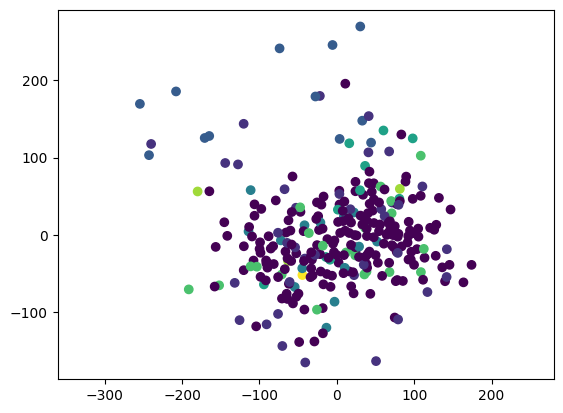

In [15]:
# recovering with PCA
model = PCA(2)
X_new = model.fit_transform(train_data)
plt.axis("equal")
plt.scatter(*X_new.T,c=train_ans)

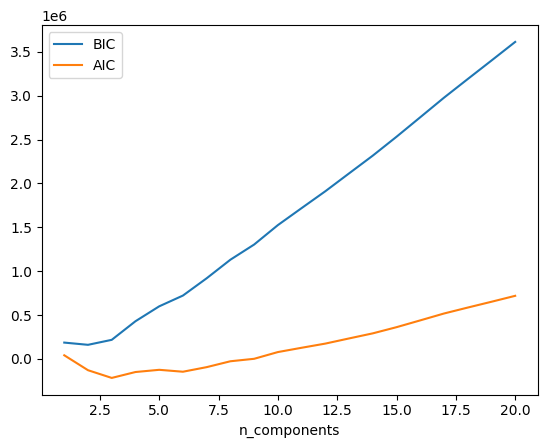

In [24]:
n_components = np.arange(1, 21)
models = [GMM(n, covariance_type='full', random_state=0).fit(train_data)
          for n in n_components]

plt.plot(n_components, [m.bic(train_data) for m in models], label='BIC')
plt.plot(n_components, [m.aic(train_data) for m in models], label='AIC')
plt.legend(loc='best')
plt.xlabel('n_components');

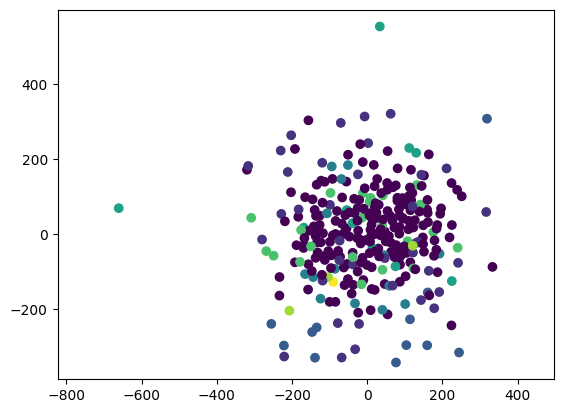

In [16]:
# recovering with PCA
model = MDS(n_components=2)
X_new = model.fit_transform(train_data)
plt.axis("equal")
plt.scatter(*X_new.T,c=train_ans)

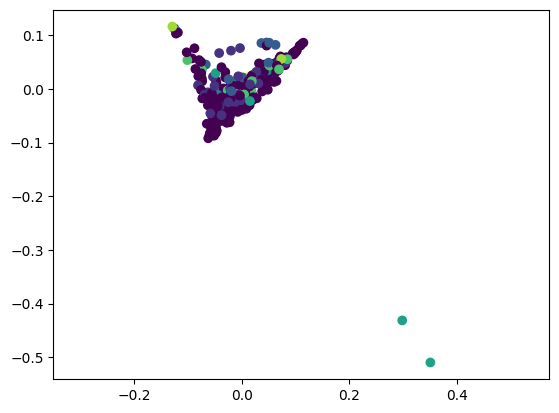

In [17]:
# recovering with PCA
model = LocallyLinearEmbedding(n_components=2)
X_new = model.fit_transform(train_data)
plt.axis("equal")
plt.scatter(*X_new.T,c=train_ans)

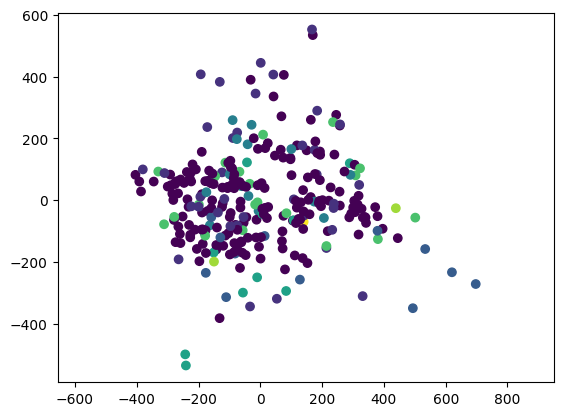

In [18]:
# recovering with PCA
model = Isomap(n_components=2)
X_new = model.fit_transform(train_data)
plt.axis("equal")
plt.scatter(*X_new.T,c=train_ans)